# Import Modules

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

---

# Read CSV

In [10]:
pd.set_option("display.max_columns", 30)

In [11]:
df = pd.read_csv("../csv_files/hr_job_placement_dataset_cleaned.csv")
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.062,83.843,75.857,Computer Science,58.222,89.566,64.474,79.549,2,No,1,Willing,Relevant,3.531,5.806,Tier 3,Not Matched,Medium,Not Required,15,No,18,Not Willing,Not Placed
1,24,Male,67.886,64.973,73.094,Electronics,71.928,54.592,61.077,73.316,1,Yes,0,Not Willing,Relevant,9.858,10.808,Tier 1,Matched,High,Required,0,No,3,Not Willing,Not Placed
2,33,Female,73.892,68.834,90.196,Information Technology,72.445,58.587,79.495,75.467,1,Yes,1,Willing,Relevant,5.802,5.477,Tier 3,Not Matched,Low,Not Required,0,No,3,Not Willing,Placed
3,31,Male,74.146,76.255,75.587,Mechanical,78.856,61.022,53.740,73.676,2,No,0,Not Willing,Relevant,2.130,9.981,Tier 2,Matched,Low,Not Required,0,Yes,6,Willing,Not Placed
4,28,Male,60.476,65.786,80.801,Information Technology,68.287,65.714,61.438,88.995,1,No,0,Willing,Not Relevant,7.948,8.921,Tier 2,Matched,Medium,Not Required,0,No,3,Willing,Not Placed


In [12]:
df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status'],
      dtype='str')

In [13]:
df.describe()

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,27.506080,70.014665,72.061051,74.006590,68.034630,63.994173,66.098348,73.94074,1.400820,1.493720,4.844961,8.002052,20.105900,3.057660
std,4.026225,7.777048,7.763125,6.947612,11.855683,9.913716,9.899850,11.79933,1.185155,1.375674,2.127102,3.136701,24.470191,4.384532
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.00000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.898750,66.966750,69.297500,59.942750,57.192500,59.249750,65.86375,1.000000,0.000000,3.323000,5.669000,0.000000,0.000000
50%,27.000000,70.003000,72.061000,73.992000,67.999000,63.946500,66.024000,74.00450,1.000000,1.000000,4.807000,7.856500,15.000000,0.000000
75%,31.000000,75.078250,77.147000,78.712250,76.065250,70.703000,72.836250,82.11725,2.000000,2.000000,6.298000,10.093000,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.00000,8.000000,5.000000,13.845000,26.525000,90.000000,18.000000


In [14]:
df.skew(numeric_only=True)

age_years                 -0.000926
ssc_percentage             0.051873
hsc_percentage             0.006084
degree_percentage          0.023993
technical_score            0.033183
aptitude_score             0.056067
communication_score        0.102179
skills_match_percentage   -0.047111
certifications_count       0.854001
years_of_experience        0.708171
previous_ctc_lpa           0.196318
expected_ctc_lpa           0.426480
notice_period_days         1.372192
employment_gap_months      1.741472
dtype: float64

In [15]:
cat_columns = []
numeric_columns = []

for column in df.columns:
    if df[column].dtype == "str":
        cat_columns.append(column)
    else:
        numeric_columns.append(column)

---

# Pre-Processing and Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

## Label Encoding for Binary Categorical Columns

In [17]:
# For Label Encoding
categorical_features = [
    "gender",
    "internship_experience",
    "career_switch_willingness",
    "relevant_experience",
    "job_role_match",
    "bond_requirement",
    "layoff_history",
    "relocation_willingness"
]

In [18]:
label_encoders = {}

for column in categorical_features:

    la_enoder = LabelEncoder()

    df[column] = la_enoder.fit_transform(df[column])

    label_encoders[column] = la_enoder

In [19]:
status_encoder = LabelEncoder()

df["status"] = status_encoder.fit_transform(df["status"])

---

## Ordinal Encoding for Ordered Categorical Columns

In [20]:
company_tier_encoder = OrdinalEncoder(
    categories=[["Tier 1", "Tier 2", "Tier 3"]]
)

df["company_tier"] = company_tier_encoder.fit_transform(df[["company_tier"]])

df["company_tier"] = df["company_tier"].astype(int)

In [21]:
competition_level_encoder = OrdinalEncoder(
    categories=[["Low", "Medium", "High"]]
)

df["competition_level"] = competition_level_encoder.fit_transform(df[["competition_level"]])

df["competition_level"] = df["competition_level"].astype(int)

---

## OneHot Encode - Multiclass Categorical Column

In [22]:
degree_spec_encoder = OneHotEncoder()

degree_spec_encoded = degree_spec_encoder.fit_transform(df[["degree_specialization"]]).toarray()

degree_spec_encoded = pd.DataFrame(degree_spec_encoded, columns=degree_spec_encoder.get_feature_names_out(["degree_specialization"]))


In [23]:
# Converting Float into Integer -> degree_specialization
for column in degree_spec_encoded.columns:
    degree_spec_encoded[column] = degree_spec_encoded[column].astype(int)

In [24]:
degree_spec_encoded

,degree_specialization_Computer Science,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others
0,1,0,0,0,0
1,0,1,0,0,0
2,0,0,1,0,0
3,0,0,0,1,0
4,0,0,1,0,0
...,...,...,...,...,...
49995,0,1,0,0,0
49996,0,0,0,1,0
49997,0,0,0,1,0
49998,0,0,0,0,1


---

In [25]:
# For Correlation check without "Degree Specializztion"

df_copy = df.drop(columns="degree_specialization")

In [26]:
df = pd.concat([df.drop(columns=["degree_specialization", "status"]), degree_spec_encoded, df["status"]], axis=1)

In [27]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,degree_specialization_Computer Science,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,status
0,27,1,65.062,83.843,75.857,58.222,89.566,64.474,79.549,2,0,1,1,1,3.531,5.806,2,1,1,0,15,0,18,0,1,0,0,0,0,0
1,24,1,67.886,64.973,73.094,71.928,54.592,61.077,73.316,1,1,0,0,1,9.858,10.808,0,0,2,1,0,0,3,0,0,1,0,0,0,0
2,33,0,73.892,68.834,90.196,72.445,58.587,79.495,75.467,1,1,1,1,1,5.802,5.477,2,1,0,0,0,0,3,0,0,0,1,0,0,1
3,31,1,74.146,76.255,75.587,78.856,61.022,53.740,73.676,2,0,0,0,1,2.130,9.981,1,0,0,0,0,1,6,1,0,0,0,1,0,0
4,28,1,60.476,65.786,80.801,68.287,65.714,61.438,88.995,1,0,0,1,0,7.948,8.921,1,0,1,0,0,0,3,1,0,0,1,0,0,0


---

## Storing Encoders as Pickle Files

In [28]:
import pickle as pkl

In [29]:
with open("../encoded_files/label_encoders.pkl", "wb") as file:
    pkl.dump(label_encoders, file)


with open("../encoded_files/company_tier_encoder.pkl", "wb") as file:
    pkl.dump(company_tier_encoder, file)


with open("../encoded_files/competition_level_encoder.pkl", "wb") as file:
    pkl.dump(competition_level_encoder, file)


with open("../encoded_files/degree_spec_encoder.pkl", "wb") as file:
    pkl.dump(degree_spec_encoder, file)
    

with open("../encoded_files/status_encoder.pkl", "wb") as file:
    pkl.dump(status_encoder, file)

---

# EDA

In [30]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,degree_specialization_Computer Science,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,status
0,27,1,65.062,83.843,75.857,58.222,89.566,64.474,79.549,2,0,1,1,1,3.531,5.806,2,1,1,0,15,0,18,0,1,0,0,0,0,0
1,24,1,67.886,64.973,73.094,71.928,54.592,61.077,73.316,1,1,0,0,1,9.858,10.808,0,0,2,1,0,0,3,0,0,1,0,0,0,0
2,33,0,73.892,68.834,90.196,72.445,58.587,79.495,75.467,1,1,1,1,1,5.802,5.477,2,1,0,0,0,0,3,0,0,0,1,0,0,1
3,31,1,74.146,76.255,75.587,78.856,61.022,53.740,73.676,2,0,0,0,1,2.130,9.981,1,0,0,0,0,1,6,1,0,0,0,1,0,0
4,28,1,60.476,65.786,80.801,68.287,65.714,61.438,88.995,1,0,0,1,0,7.948,8.921,1,0,1,0,0,0,3,1,0,0,1,0,0,0


In [31]:
df["status"].value_counts()

status
0    34870
1    15130
Name: count, dtype: int64

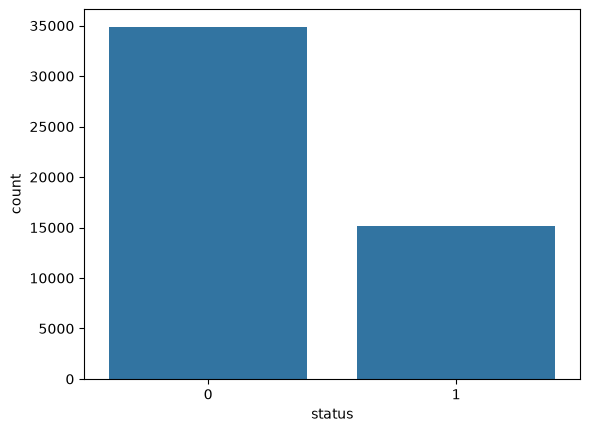

In [32]:
sns.countplot(x="status", data=df)
plt.show()

## Univariate Analysis

In [33]:
df.describe()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,degree_specialization_Computer Science,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,27.506080,0.497260,70.014665,72.061051,74.006590,68.034630,63.994173,66.098348,73.94074,1.400820,0.476720,1.493720,0.282640,0.674380,4.844961,8.002052,0.858140,0.231600,0.784080,0.218800,20.105900,0.110500,3.057660,0.704380,0.198140,0.201040,0.200240,0.197700,0.202880,0.302600
std,4.026225,0.499997,7.777048,7.763125,6.947612,11.855683,9.913716,9.899850,11.79933,1.185155,0.499463,1.375674,0.450287,0.468611,2.127102,3.136701,0.781171,0.421859,0.755718,0.413437,24.470191,0.313515,4.384532,0.456326,0.398602,0.400782,0.400184,0.398269,0.402148,0.459388
min,21.000000,0.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,0.000000,64.898750,66.966750,69.297500,59.942750,57.192500,59.249750,65.86375,1.000000,0.000000,0.000000,0.000000,0.000000,3.323000,5.669000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,70.003000,72.061000,73.992000,67.999000,63.946500,66.024000,74.00450,1.000000,0.000000,1.000000,0.000000,1.000000,4.807000,7.856500,1.000000,0.000000,1.000000,0.000000,15.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,31.000000,1.000000,75.078250,77.147000,78.712250,76.065250,70.703000,72.836250,82.11725,2.000000,1.000000,2.000000,1.000000,1.000000,6.298000,10.093000,1.000000,0.000000,1.000000,0.000000,30.000000,0.000000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,34.000000,1.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.00000,8.000000,1.000000,5.000000,1.000000,1.000000,13.845000,26.525000,2.000000,1.000000,2.000000,1.000000,90.000000,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Numeric Features

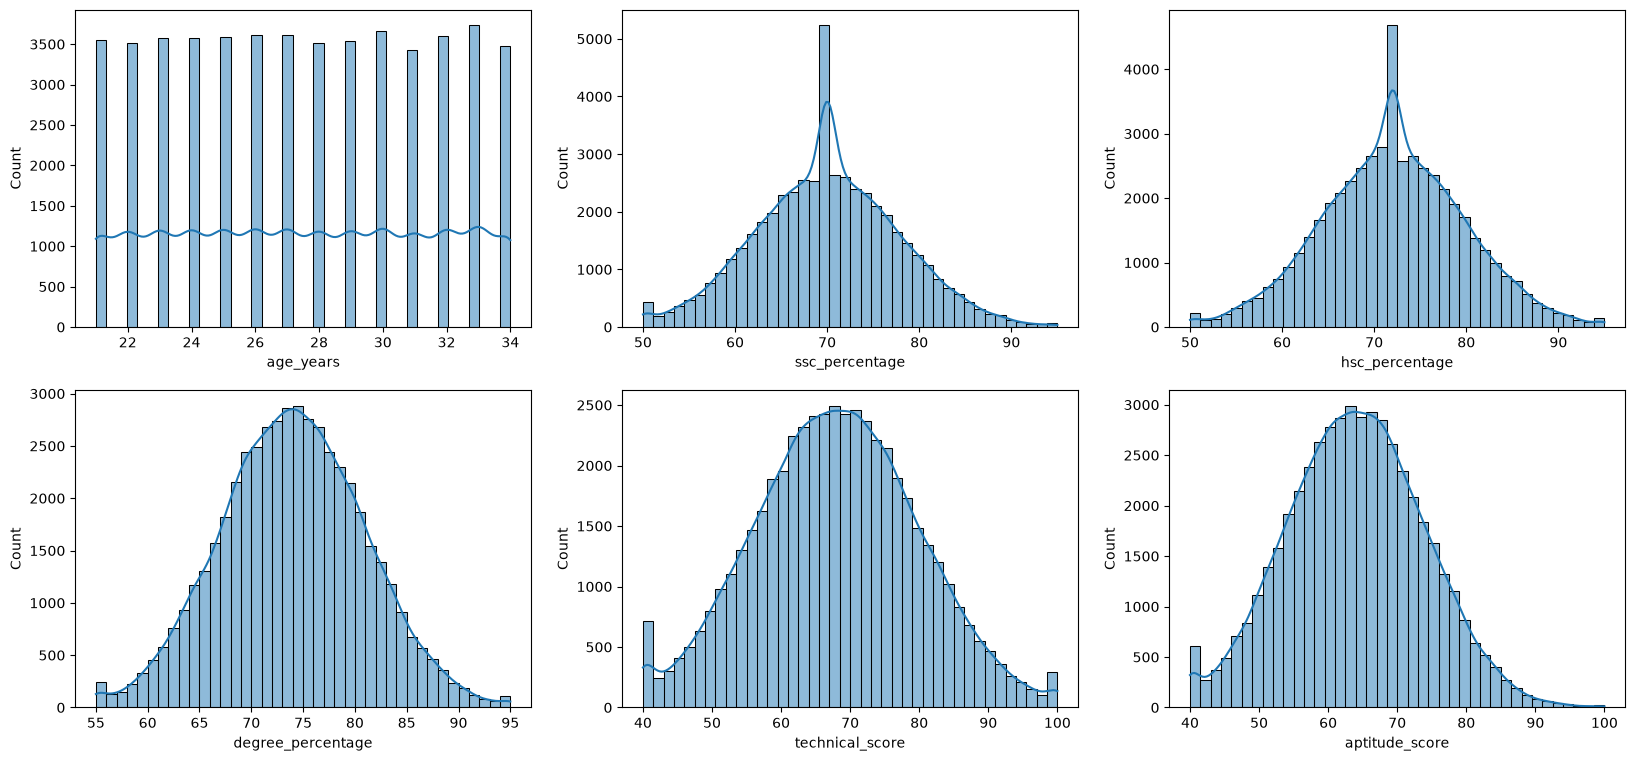

In [34]:
plt.figure(figsize=(20, 14))

for i, column in enumerate(numeric_columns[:6], 1):
    plt.subplot(3,3, i)
    sns.histplot(df[column],bins=40, kde=True)

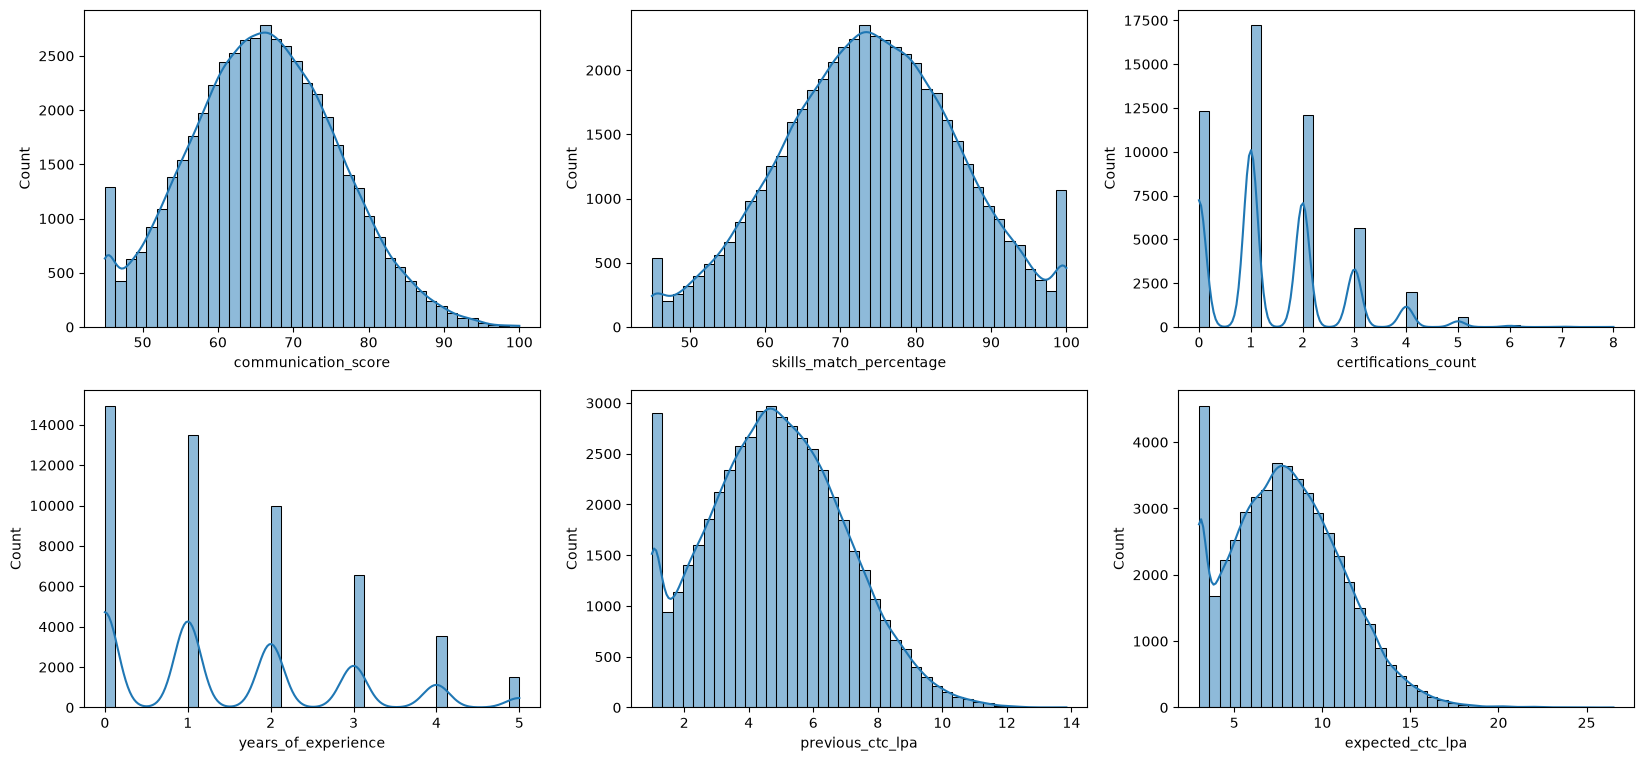

In [35]:
plt.figure(figsize=(20, 14))

for i, column in enumerate(numeric_columns[6:12], 1):
    plt.subplot(3,3, i)
    sns.histplot(df[column],bins=40, kde=True)

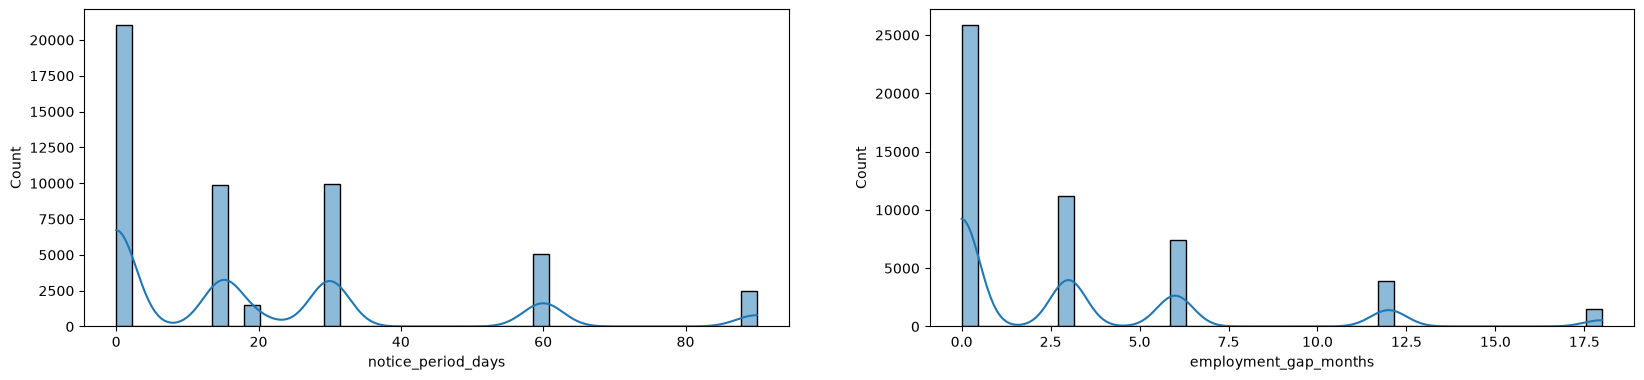

In [36]:
plt.figure(figsize=(20, 14))

for i, column in enumerate(numeric_columns[12:], 1):
    plt.subplot(3,2, i)
    sns.histplot(df[column],bins=40, kde=True)

- There are no outliers in any of the numerical features so I skiped outliers check.

- Continuous columns are normally distributed and few columns are skewed.


---

### Categorical Features

In [37]:
len(cat_columns)

12

In [38]:
cat_columns.remove("degree_specialization")

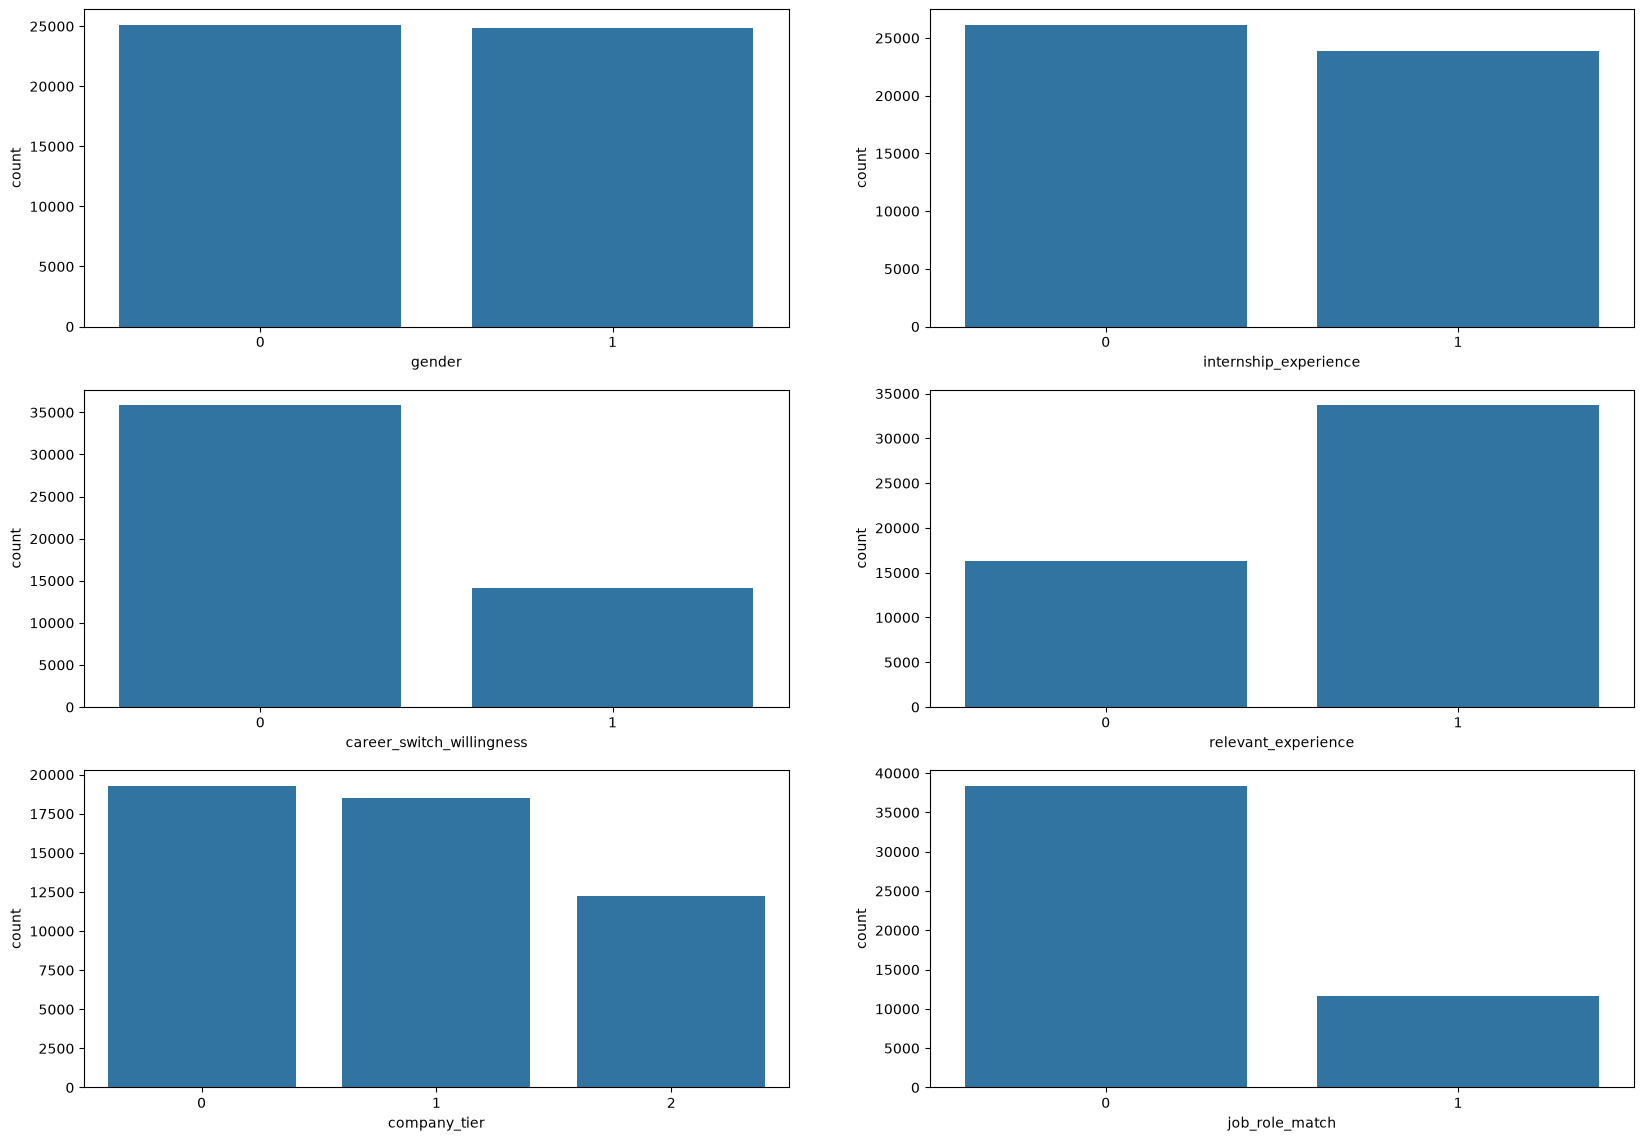

In [39]:
plt.figure(figsize=(20, 14))

for i, column in enumerate(cat_columns[:6], 1):
    plt.subplot(3,2, i)
    sns.countplot(x=column, data=df)

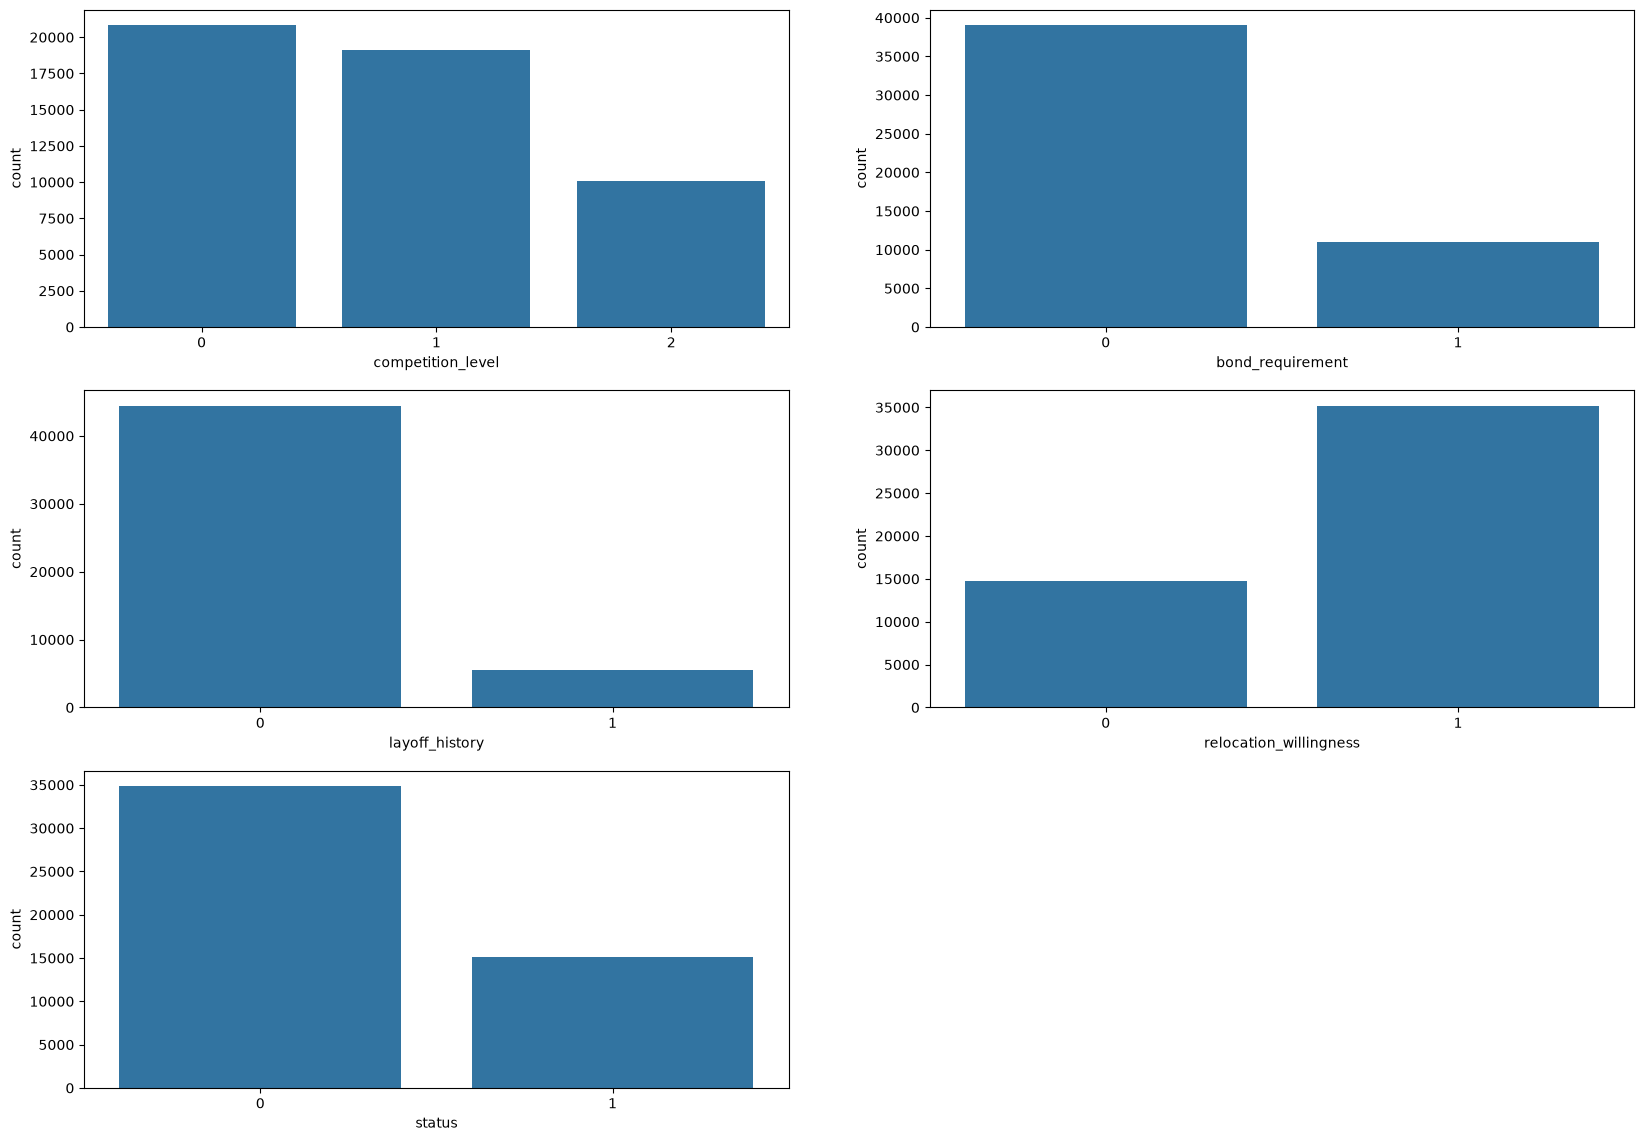

In [40]:
plt.figure(figsize=(20, 14))

for i, column in enumerate(cat_columns[6:], 1):
    plt.subplot(3,2, i)
    sns.countplot(x=column, data=df)

---

## Bi-Variate 

In [41]:
df_corr = df_copy.corr()

<Axes: >

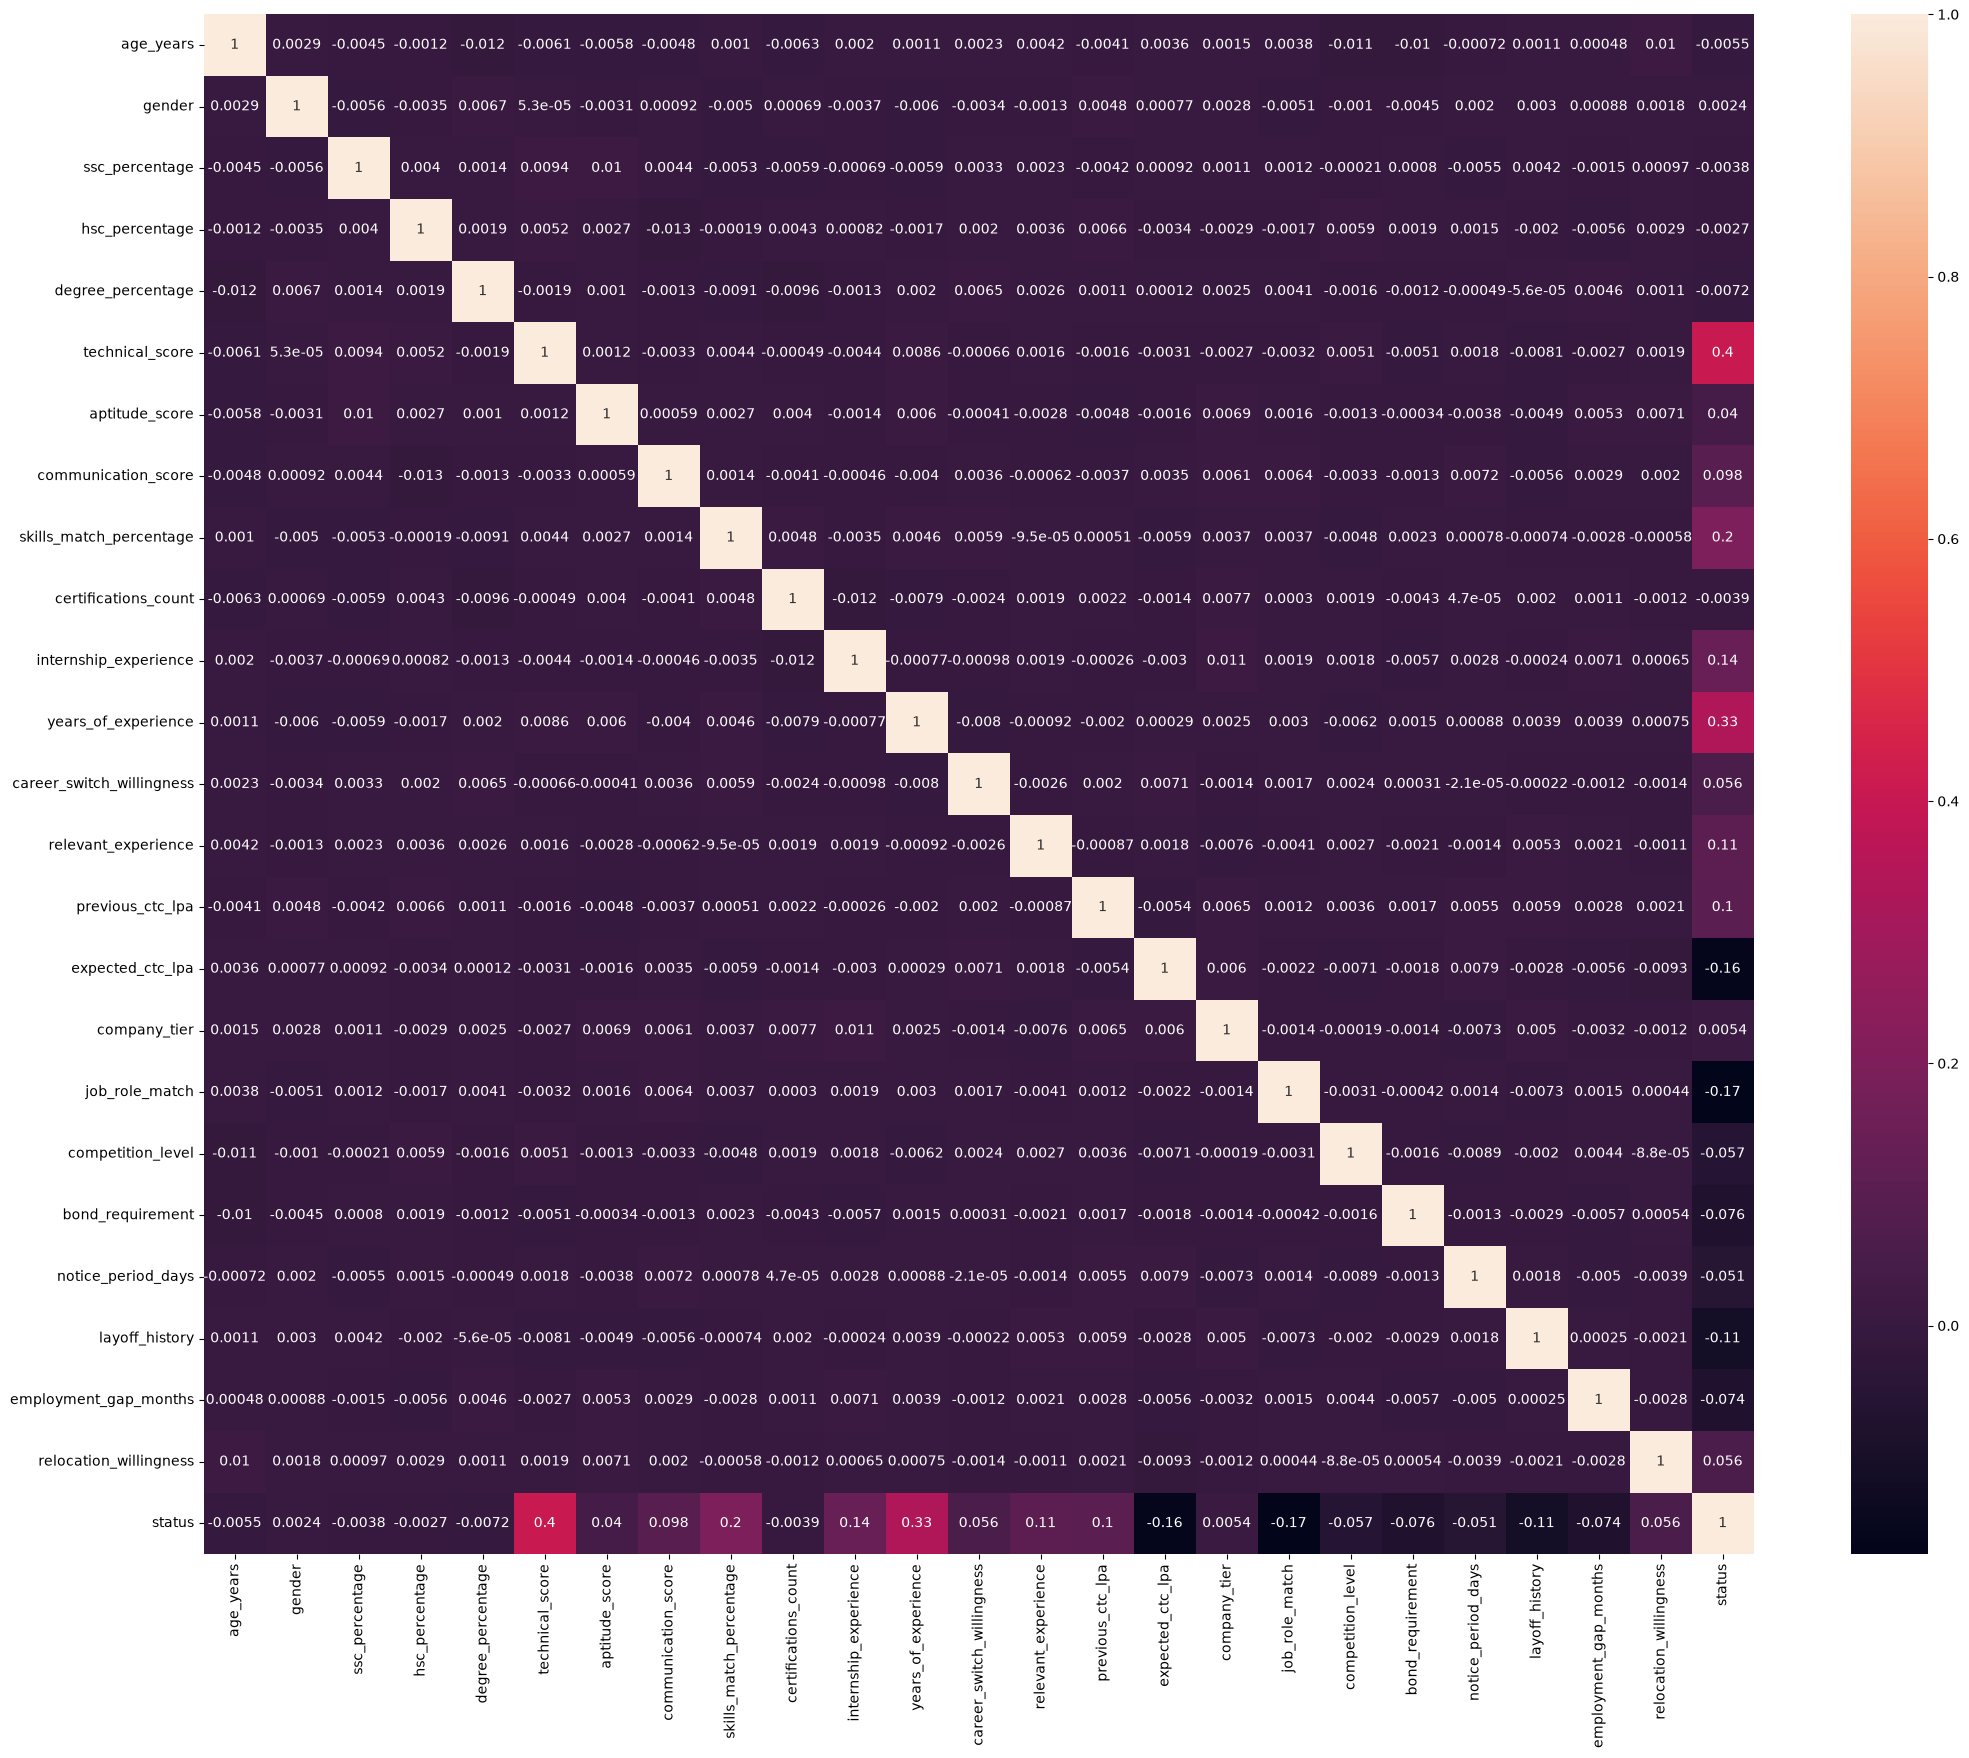

In [42]:
plt.figure(figsize=(25, 20))

sns.heatmap(df_corr, annot=True)

In [43]:
multi_collinearity = []

for i in range(len(df_corr.columns)):
    for j in range(i):
        if abs(df_corr.iloc[i, j]) > 0.85:
            multi_collinearity.append((df_corr.columns[i], df_corr.columns[j]))

In [44]:
multi_collinearity

[]

- No multicollinearity exists.

---

# Machine Learning Implement

In [45]:
df[numeric_columns]

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
0,27,65.062,83.843,75.857,58.222,89.566,64.474,79.549,2,1,3.531,5.806,15,18
1,24,67.886,64.973,73.094,71.928,54.592,61.077,73.316,1,0,9.858,10.808,0,3
2,33,73.892,68.834,90.196,72.445,58.587,79.495,75.467,1,1,5.802,5.477,0,3
3,31,74.146,76.255,75.587,78.856,61.022,53.740,73.676,2,0,2.130,9.981,0,6
4,28,60.476,65.786,80.801,68.287,65.714,61.438,88.995,1,0,7.948,8.921,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29,76.383,82.706,81.790,71.956,74.281,65.614,61.998,1,2,1.979,7.495,0,6
49996,32,80.030,68.804,69.179,53.489,51.797,75.373,77.767,2,0,5.064,11.914,30,0
49997,28,61.801,69.772,79.778,60.530,40.000,54.852,54.749,1,0,3.309,12.903,0,3
49998,34,71.812,76.841,86.810,67.612,44.374,69.899,92.333,3,0,1.700,7.567,60,0


## Import Modules

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

## Train-Test Split

In [47]:
df.shape

(50000, 30)

In [48]:
x = df.drop("status", axis=1)
y = df["status"]

In [49]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [51]:
x_train.columns.tolist()

['age_years',
 'gender',
 'ssc_percentage',
 'hsc_percentage',
 'degree_percentage',
 'technical_score',
 'aptitude_score',
 'communication_score',
 'skills_match_percentage',
 'certifications_count',
 'internship_experience',
 'years_of_experience',
 'career_switch_willingness',
 'relevant_experience',
 'previous_ctc_lpa',
 'expected_ctc_lpa',
 'company_tier',
 'job_role_match',
 'competition_level',
 'bond_requirement',
 'notice_period_days',
 'layoff_history',
 'employment_gap_months',
 'relocation_willingness',
 'degree_specialization_Computer Science',
 'degree_specialization_Electronics',
 'degree_specialization_Information Technology',
 'degree_specialization_Mechanical',
 'degree_specialization_Others']

## Standardization Numeric Columns

In [136]:
df[numeric_columns]

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
0,27,65.062,83.843,75.857,58.222,89.566,64.474,79.549,2,1,3.531,5.806,15,18
1,24,67.886,64.973,73.094,71.928,54.592,61.077,73.316,1,0,9.858,10.808,0,3
2,33,73.892,68.834,90.196,72.445,58.587,79.495,75.467,1,1,5.802,5.477,0,3
3,31,74.146,76.255,75.587,78.856,61.022,53.740,73.676,2,0,2.130,9.981,0,6
4,28,60.476,65.786,80.801,68.287,65.714,61.438,88.995,1,0,7.948,8.921,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29,76.383,82.706,81.790,71.956,74.281,65.614,61.998,1,2,1.979,7.495,0,6
49996,32,80.030,68.804,69.179,53.489,51.797,75.373,77.767,2,0,5.064,11.914,30,0
49997,28,61.801,69.772,79.778,60.530,40.000,54.852,54.749,1,0,3.309,12.903,0,3
49998,34,71.812,76.841,86.810,67.612,44.374,69.899,92.333,3,0,1.700,7.567,60,0


In [137]:
scaler = StandardScaler()

x_train[numeric_columns] = scaler.fit_transform(x_train[numeric_columns])

x_test[numeric_columns] = scaler.transform(x_test[numeric_columns])

### Storing scaler as Pickle File

In [138]:
with open("../encoded_files/scaler.pkl", "wb") as file:
    pkl.dump(scaler, file)

## Model Implement

In [139]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Naive Bayes" : GaussianNB(),
    "KNN" : KNeighborsClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "XG Boost" : XGBClassifier()
}

In [140]:
for key in models:

    model = models[key]

    model.fit(x_train, y_train)

    # Prediction for Train and Test data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Perfomance Metrics for Training Data
    train_confusion = confusion_matrix(y_train_pred, y_train)
    train_accuracy = accuracy_score(y_train_pred, y_train)
    train_precision = precision_score(y_train_pred, y_train)
    train_recall = recall_score(y_train_pred, y_train)
    train_f1_score = f1_score(y_train_pred, y_train)

    # Perfomance Metrics for Training Data
    test_confusion = confusion_matrix(y_test_pred, y_test)
    test_accuracy = accuracy_score(y_test_pred, y_test)
    test_precision = precision_score(y_test_pred, y_test)
    test_recall = recall_score(y_test_pred, y_test)
    test_f1_score = f1_score(y_test_pred, y_test)

    # Print Training perfomance
    print(key)
    print(f"Accuracy Score: {train_accuracy}")
    print(f"Precision Score: {train_precision}")
    print(f"Recall Score: {train_recall}")
    print(f"F1 Score: {train_f1_score}")
    print("-"*40)

    # Print Testing perfomance
    print(f"Accuracy Score: {test_accuracy}")
    print(f"Precision Score: {test_precision}")
    print(f"Recall Score: {test_recall}")
    print(f"F1 Score: {test_f1_score}")
    print("="*40)
    print()


Logistic Regression
Accuracy Score: 0.865975
Precision Score: 0.7384742951907131
Recall Score: 0.8014037613605687
F1 Score: 0.7686531739524447
----------------------------------------
Accuracy Score: 0.8718
Precision Score: 0.7579804560260587
Recall Score: 0.8119330076762038
F1 Score: 0.7840296495956873

Naive Bayes
Accuracy Score: 0.8502
Precision Score: 0.722636815920398
Recall Score: 0.7670304523851434
F1 Score: 0.7441721458457861
----------------------------------------
Accuracy Score: 0.8491
Precision Score: 0.7276872964169381
Recall Score: 0.7684898520811834
F1 Score: 0.7475322067927054

KNN
Accuracy Score: 0.88165
Precision Score: 0.7922885572139303
Recall Score: 0.8108452138492872
F1 Score: 0.8014594866633116
----------------------------------------
Accuracy Score: 0.8043
Precision Score: 0.6732899022801303
Recall Score: 0.6842105263157895
F1 Score: 0.6787062879658513

Decision Tree
Accuracy Score: 1.0
Precision Score: 1.0
Recall Score: 1.0
F1 Score: 1.0
-----------------------

- Based on the above results, Logistic Regression, Random Forest, and XGBoost performed better than the other models.

- Therefore, these models were chosen for hyperparameter optimization

### Hyper Parameter Tuning - Finding Best Params

In [141]:
logistic_params = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1],
    "solver" : ["liblinear"]
}

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 4, 8]
}

xg_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.2, 0.4, 0.6],
    "colsample_bytree": [0.5, 0.6, 0.7]
}

In [142]:
models = [
    ("Logistic Regression", LogisticRegression(), logistic_params),
    ("Random Forest", RandomForestClassifier(random_state=42), rf_params),
    ("XG Boost", XGBClassifier(random_state=42), xg_params)
]

iterations = {
    "Logistic Regression": 10,
    "Random Forest": 20,
    "XG Boost": 40
}

In [143]:
best_param = {}

for name, model, params in models:

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        scoring="accuracy",
        cv=5,
        n_iter=iterations[name],
        n_jobs=-1,
    )

    random_search.fit(x_train, y_train)
    best_param[name] = random_search.best_params_

c:\Users\rjeev\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\rjeev\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\rjeev\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warni

In [150]:
best_param

{'Logistic Regression': {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1},
 'Random Forest': {'n_estimators': 300,
  'min_samples_split': 8,
  'max_depth': None},
 'XG Boost': {'subsample': 0.4,
  'n_estimators': 300,
  'max_depth': 3,
  'learning_rate': 0.1,
  'colsample_bytree': 0.7}}

### Retraining Model with Best Hyperparameters

In [157]:
import warnings
warnings.filterwarnings("ignore")

In [158]:
best_param

{'Logistic Regression': {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1},
 'Random Forest': {'n_estimators': 300,
  'min_samples_split': 8,
  'max_depth': None},
 'XG Boost': {'subsample': 0.4,
  'n_estimators': 300,
  'max_depth': 3,
  'learning_rate': 0.1,
  'colsample_bytree': 0.7}}

In [159]:
models = {
    "Logistic Regression" : LogisticRegression(
        solver='liblinear', 
        penalty='l1', 
        C=0.1
    ),
    "Random Forest" : RandomForestClassifier(
        n_estimators=300,
        min_samples_split=8,
        max_depth=None
    ),
    "XG Boost" : XGBClassifier(
        subsample=0.4,
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        colsample_bytree=0.7
    )
}

In [160]:
for key in models:

    model = models[key]

    model.fit(x_train, y_train)

    # Prediction for Train and Test data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Perfomance Metrics for Training Data
    train_confusion = confusion_matrix(y_train_pred, y_train)
    train_accuracy = accuracy_score(y_train_pred, y_train)
    train_precision = precision_score(y_train_pred, y_train)
    train_recall = recall_score(y_train_pred, y_train)
    train_f1_score = f1_score(y_train_pred, y_train)

    # Perfomance Metrics for Training Data
    test_confusion = confusion_matrix(y_test_pred, y_test)
    test_accuracy = accuracy_score(y_test_pred, y_test)
    test_precision = precision_score(y_test_pred, y_test)
    test_recall = recall_score(y_test_pred, y_test)
    test_f1_score = f1_score(y_test_pred, y_test)

    # Print Training perfomance
    print(key)
    print(f"Accuracy Score: {train_accuracy}")
    print(f"Precision Score: {train_precision}")
    print(f"Recall Score: {train_recall}")
    print(f"F1 Score: {train_f1_score}")
    print("-"*40)

    # Print Testing perfomance
    print(f"Accuracy Score: {test_accuracy}")
    print(f"Precision Score: {test_precision}")
    print(f"Recall Score: {test_recall}")
    print(f"F1 Score: {test_f1_score}")
    print("="*40)
    print()


Logistic Regression
Accuracy Score: 0.86635
Precision Score: 0.7379767827529021
Recall Score: 0.8028143604546275
F1 Score: 0.769031366110775
----------------------------------------
Accuracy Score: 0.8721
Precision Score: 0.7576547231270359
Recall Score: 0.8130024466969591
F1 Score: 0.7843533974034733

Random Forest
Accuracy Score: 0.9963
Precision Score: 0.9918739635157545
Recall Score: 0.9958374958374958
F1 Score: 0.9938517779993353
----------------------------------------
Accuracy Score: 0.8913
Precision Score: 0.7579804560260587
Recall Score: 0.871209284912018
F1 Score: 0.810660163734541

XG Boost
Accuracy Score: 0.918525
Precision Score: 0.8556384742951907
Recall Score: 0.8717580468023992
F1 Score: 0.8636230489182742
----------------------------------------
Accuracy Score: 0.9086
Precision Score: 0.8433224755700326
Recall Score: 0.8567174056915949
F1 Score: 0.849967170059094



### Final Model Training with XGBoost

In [172]:
xg_boost = models["XG Boost"]

xg_boost.fit(x_train, y_train)

# Prediction for Train and Test data
y_train_pred = xg_boost.predict(x_train)
y_test_pred = xg_boost.predict(x_test)

# Perfomance Metrics for Training Data
train_confusion = confusion_matrix(y_train_pred, y_train)
train_accuracy = accuracy_score(y_train_pred, y_train)
train_precision = precision_score(y_train_pred, y_train)
train_recall = recall_score(y_train_pred, y_train)
train_f1_score = f1_score(y_train_pred, y_train)

# Perfomance Metrics for Training Data
test_confusion = confusion_matrix(y_test_pred, y_test)
test_accuracy = accuracy_score(y_test_pred, y_test)
test_precision = precision_score(y_test_pred, y_test)
test_recall = recall_score(y_test_pred, y_test)
test_f1_score = f1_score(y_test_pred, y_test)

# Print Training perfomance
print(key)
print(f"Accuracy Score: {train_accuracy}")
print(f"Precision Score: {train_precision}")
print(f"Recall Score: {train_recall}")
print(f"F1 Score: {train_f1_score}")
print("-"*40)

# Print Testing perfomance
print(f"Accuracy Score: {test_accuracy}")
print(f"Precision Score: {test_precision}")
print(f"Recall Score: {test_recall}")
print(f"F1 Score: {test_f1_score}")
print("="*40)
print()


XG Boost
Accuracy Score: 0.918525
Precision Score: 0.8556384742951907
Recall Score: 0.8717580468023992
F1 Score: 0.8636230489182742
----------------------------------------
Accuracy Score: 0.9086
Precision Score: 0.8433224755700326
Recall Score: 0.8567174056915949
F1 Score: 0.849967170059094



- I selected **XGBoost** as my final machine learning model.

- The training and testing performance metrics are very close.

### Storing Model as Pickle File

In [167]:
with open("../encoded_files/ml_model.pkl", "wb") as file:
    pkl.dump(xg_boost, file)